# k-NN con el dataset Iris

Nombre: Juan Sebastian Manrique Moreno

Código: 20202107016

Correo: jsmanriquem@udistrital.edu.co

## Importación de las librerías necesarias

A continuación las librerías básicas necesarias para el funcionamiento del código.

In [1]:
# Manejo del dataset
import pandas as pd
# Manejo de operaciones matemáticas entre otros
import numpy as np
# Manejo de gráficos
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

Configuración de la librería `maplotlib` para la impresión de la gráfica final.

In [2]:
from matplotlib.colors import ListedColormap

plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')

Importación de las librerías necesarias de `sklearn` usadas para Machine Learning y la implementación del método _k-NN_, junto a las métricas necesarias.

In [3]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

## Importación del dataset Iris

El siguiente código importa el dataset _Iris_ y lo configura con tal suerte que su visualización sea la más óptima.

In [20]:
col_names = ['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width','Species']
csv_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
df = pd.read_csv(csv_url, names = col_names)
df

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


Luego, usamos el método `.describe()` para conocer un poco más sobre el dataset que se importó.

In [5]:
df.describe()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Con ayuda del método `.hist()` podemos hacer un histograma por cada característica o feature del dataset donde se analizan los valores únicos que hay y se contrasta con la frecuencia de los mismos. Simplemente es una forma diferente de visualizar los datos.

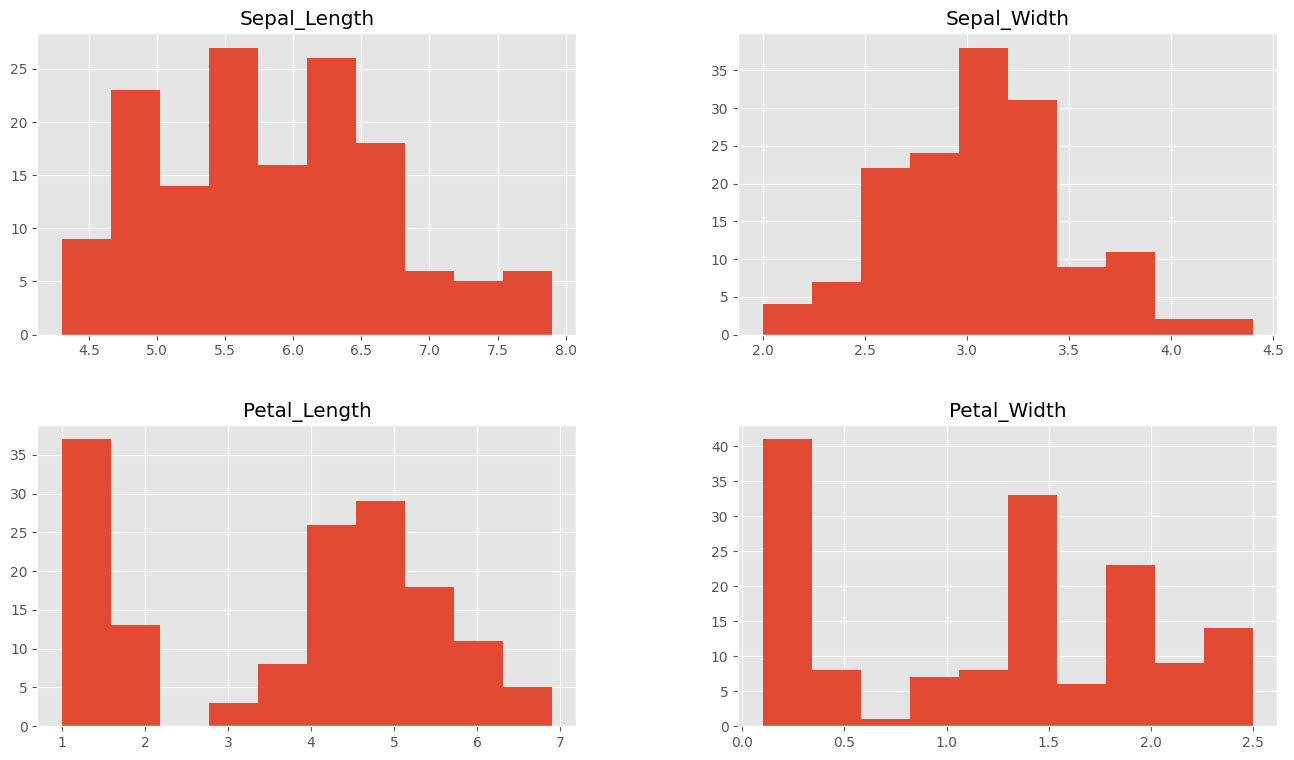

In [6]:
df.hist()
plt.show()

## Manejo de los datos y entrenamiento del modelo

Primero se realiza la división de los datos en las características (`X`) y en las etiquetas (`Y`), que para este caso solamente se usarán dos columnas en `X`, la columna correspondiente a *Sepal_Width* y *Petal_Width*.

In [7]:
X = df.drop(df.columns[[0,2,4]], axis=1) # Features
Y = df['Species'] # Labels

Luego se grafica una representación de los datos, es decir, con base en las dos columnas de `X` se mira cuáles son correspondientemente a su etiqueta en `Y` y se hace un pequeño mapa de los datos. Para ello se usa el fragmento de código a continuación:

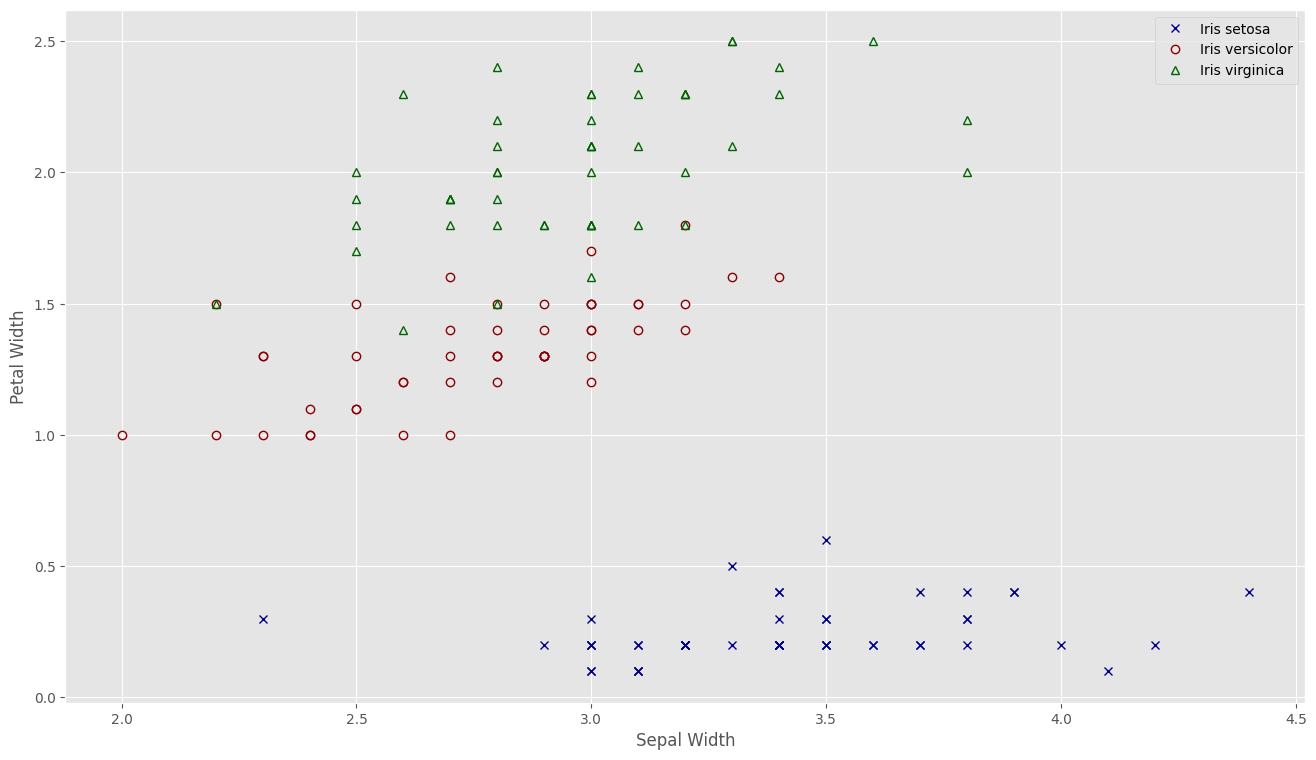

In [8]:
# Obtener características para cada etiqueta
X0 = X[Y == 'Iris-setosa']
X1 = X[Y == 'Iris-versicolor']
X2 = X[Y == 'Iris-virginica']

plt.figure() # Se instancia una figura

# Se realiza la división para aquellos que tengan la etiqueta "Iris-setosa"
plt.plot(X0[:150]['Sepal_Width'], X0[:150]['Petal_Width'], 'x', mec='darkblue', label='Iris setosa')
# Se realiza la división para aquellos que tengan la etiqueta "Iris-versicolor"
plt.plot(X1[:150]['Sepal_Width'], X1[:150]['Petal_Width'], 'o', mec='darkred', mfc='none', label='Iris versicolor')
# Se realiza la división para aquellos que tengan la etiqueta "Iris-virginica"
plt.plot(X2[:150]['Sepal_Width'], X2[:150]['Petal_Width'], '^', mec='darkgreen', mfc='none', label='Iris virginica')

# Se colocan los títulos de los ejes
plt.xlabel('Sepal Width')
plt.ylabel('Petal Width')
plt.legend()
plt.show() # Imprimir el gráfico

Tras ver un poco como están distribuidos los datos que manejamos, se puede proceder con la división en los datos de entrenamiento y evaluación. Para ello usamos el método `train_test_split`.

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.20, random_state = 69)

### Un $k$ óptimo

Antes de implementar el código es preciso encontrar cual $k$ es el más óptimo para nuestro código y así tener una mayor eficiencia computacional, para lo cual usamos un ciclo `for` el cual analiza los diez primeros $k$ y nos muestra una gráfica con su puntaje de precisión.

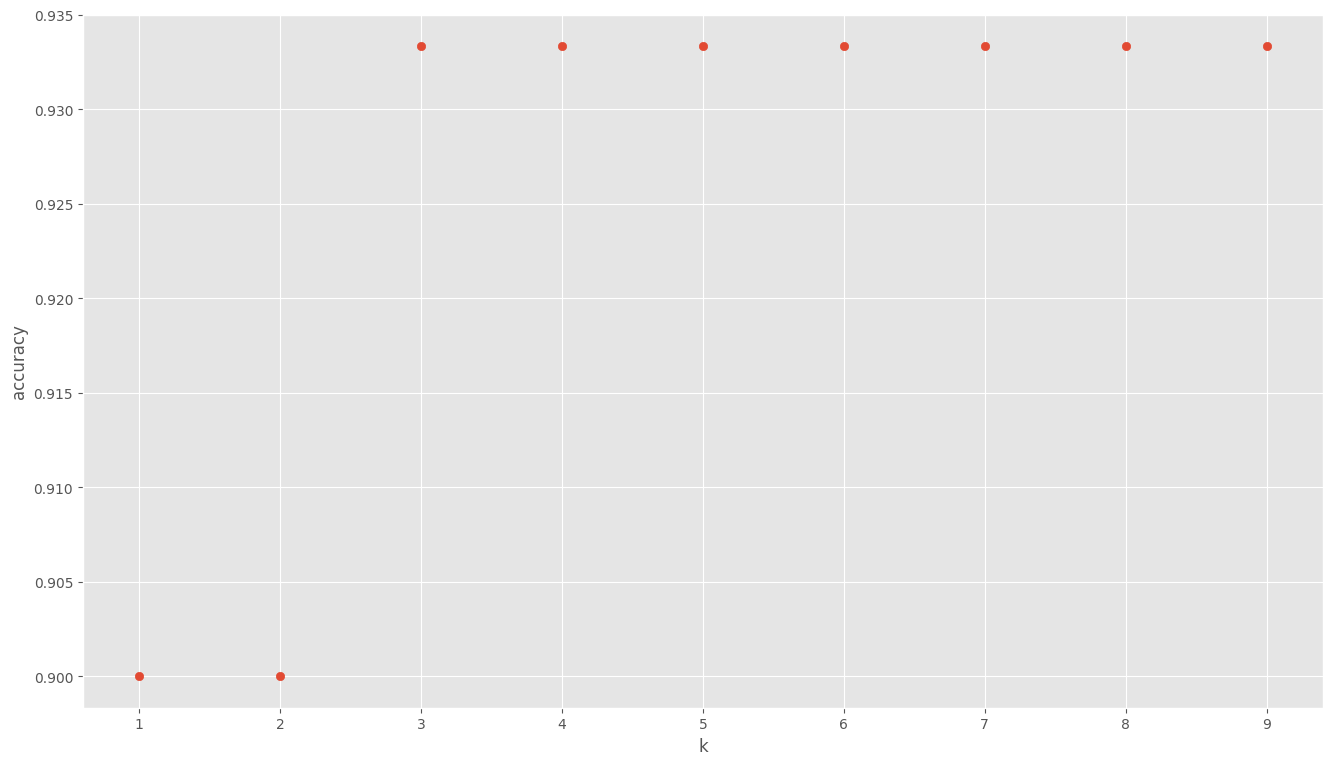

In [10]:
k_range = range(1, 10)
scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, Y_train)
    scores.append(knn.score(X_test, Y_test))
plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')
plt.scatter(k_range, scores)

Así, nos damos cuenta que a partir de $k = 3$ ya tenemos un grado alto de precisión siendo este grado constante al aumentar los valores de $k$.

### Implementación de k-NN con $k = 3$

Tras haber hallado el $k$ óptimo comparando entre la métrica de precisión, podemos ahora sí implementar *k-NN* para el entrenamiento de nuestro modelo.

In [11]:
n_neighbors = 3  # Establecer el número de vecinos

# Se instancia un objeto (veci) con la clasificación k-NN
veci = KNeighborsClassifier(n_neighbors, weights='distance')

In [12]:
# Entrenamiento del modelo
veci.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=3, weights='distance')

Tras haber entrenado el modelo, podemos evaluarlo con nuestra variable `X_test` usando el método `.predict()`.

In [13]:
Y_predic = veci.predict(X_test)

[0.9, 0.9666666666666667, 0.8666666666666667, 0.9666666666666667, 0.9333333333333333, 0.9333333333333333, 0.9666666666666667, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333]


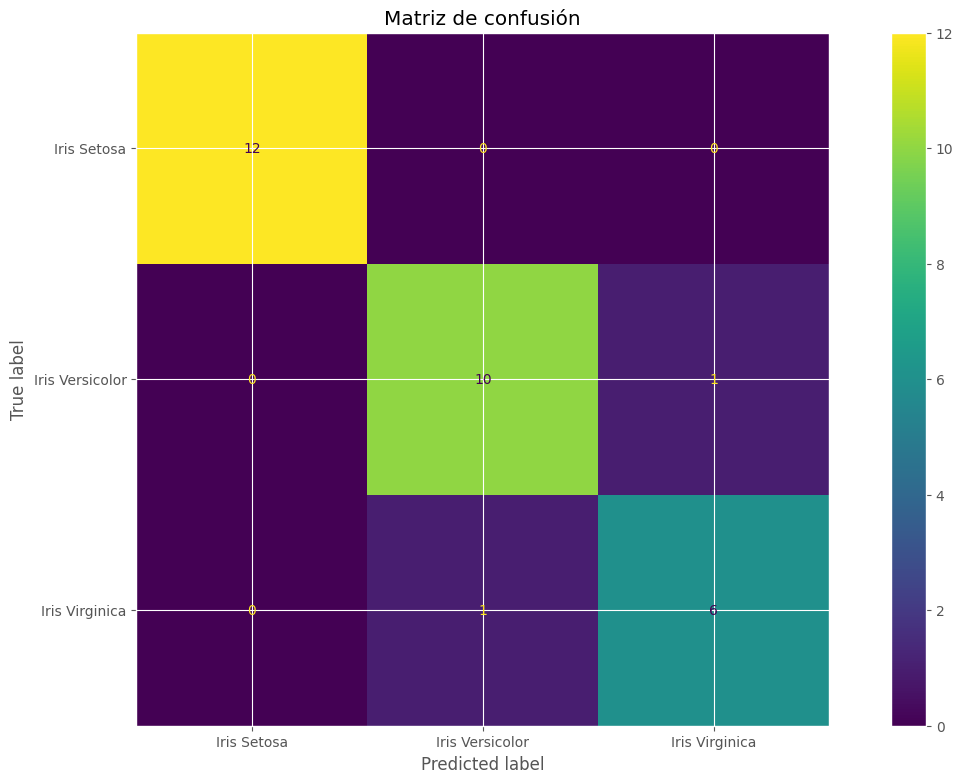

In [14]:
from io import StringIO

metricas = []

n_neighbors = 3

for i in range (0,10):
    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.20)

    knncls = KNeighborsClassifier(n_neighbors, weights='distance')
    knncls.fit(x_train, y_train)

    y_predic = knncls.predict(x_test)
    metricas.append(accuracy_score(y_test,y_predic))

print(metricas)

cmxd = confusion_matrix(y_test, y_predic)
cmxd_plot = ConfusionMatrixDisplay(confusion_matrix=cmxd, display_labels=['Iris Setosa', 'Iris Versicolor', 'Iris Virginica'])

cmxd_plot.plot()
plt.title("Matriz de confusión")
plt.show()

In [21]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Crear un DataFrame para almacenar los informes de clasificación
classification_reports = []

# Realizar el proceso de entrenamiento 10 veces
for i in range(10):
    # Dividir los datos en entrenamiento y prueba sin especificar una semilla
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

    # Crear y entrenar el modelo kNN
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred = knn.predict(X_test)

    # Generar un informe de clasificación
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Convertir el informe en un DataFrame y agregarlo a la lista de informes
    report_df = pd.DataFrame(report).transpose()
    classification_reports.append(report_df)

# Calcular la media ponderada de los valores numéricos (precision, recall, f1-score) en el informe de clasificación
weighted_report = pd.concat(classification_reports).groupby(level=0).mean()

# Imprimir el informe de clasificación ponderado
print(weighted_report)

# Calcular la matriz de confusión global
confusion_matrices = [confusion_matrix(y_test, knn.predict(X_test)) for _ in range(10)]
global_confusion_matrix = sum(confusion_matrices)

# Imprimir la matriz de confusión global
print("Global Confusion Matrix:")
print(global_confusion_matrix)

# Calcular el promedio de las puntuaciones de precisión (accuracy) en las 10 ejecuciones
accuracy_scores = [accuracy_score(y_test, knn.predict(X_test)) for _ in range(10)]
average_accuracy = sum(accuracy_scores) / len(accuracy_scores)

# Imprimir el promedio de las puntuaciones de precisión
print(f"Average Accuracy: {average_accuracy}")

              precision    recall  f1-score  support
0              1.000000  1.000000  1.000000     9.00
1              0.940677  0.973485  0.955326     9.90
2              0.969444  0.946346  0.956505    11.10
accuracy       0.970000  0.970000  0.970000     0.97
macro avg      0.970041  0.973277  0.970610    30.00
weighted avg   0.972329  0.970000  0.970132    30.00
Global Confusion Matrix:
[[ 30   0   0]
 [  0 130   0]
 [  0  10 130]]
Average Accuracy: 0.9666666666666666


In [23]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Crear un DataFrame para almacenar los informes de clasificación
classification_reports = []

# Crear una lista para almacenar los accuracy_score
accuracy_scores = []

# Realizar el proceso de entrenamiento 10 veces
for i in range(10):
    # Dividir los datos en entrenamiento y prueba sin especificar una semilla
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

    # Crear y entrenar el modelo kNN
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred = knn.predict(X_test)

    # Generar un informe de clasificación
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Convertir el informe en un DataFrame y agregarlo a la lista de informes
    report_df = pd.DataFrame(report).transpose()
    classification_reports.append(report_df)

    # Calcular el accuracy_score y agregarlo a la lista
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)

# Calcular la media ponderada de los valores numéricos (precision, recall, f1-score) en el informe de clasificación
weighted_report = pd.concat(classification_reports).groupby(level=0).mean()

# Imprimir el informe de clasificación ponderado
print(weighted_report)

# Imprimir los accuracy_score generados en cada ejecución
print("Accuracy Scores:")
for i, score in enumerate(accuracy_scores, 1):
    print(f"Iteration {i}: {score:.4f}")

# Calcular la matriz de confusión global
confusion_matrices = [confusion_matrix(y_test, knn.predict(X_test)) for _ in range(10)]
global_confusion_matrix = sum(confusion_matrices)

# Imprimir la matriz de confusión global
print("Global Confusion Matrix:")
print(global_confusion_matrix)

# Calcular el promedio de las puntuaciones de precisión (accuracy) en las 10 ejecuciones
average_accuracy = sum(accuracy_scores) / len(accuracy_scores)

# Imprimir el promedio de las puntuaciones de precisión
print(f"Average Accuracy: {average_accuracy:.4f}")

              precision    recall  f1-score    support
0              1.000000  1.000000  1.000000  10.700000
1              0.957100  0.944242  0.948970  10.100000
2              0.945909  0.938131  0.939977   9.200000
accuracy       0.966667  0.966667  0.966667   0.966667
macro avg      0.967670  0.960791  0.962982  30.000000
weighted avg   0.968400  0.966667  0.966473  30.000000
Accuracy Scores:
Iteration 1: 0.9333
Iteration 2: 0.9667
Iteration 3: 0.9667
Iteration 4: 0.9667
Iteration 5: 0.9667
Iteration 6: 0.9667
Iteration 7: 0.9667
Iteration 8: 1.0000
Iteration 9: 1.0000
Iteration 10: 0.9333
Global Confusion Matrix:
[[120   0   0]
 [  0  90  10]
 [  0  10  70]]
Average Accuracy: 0.9667


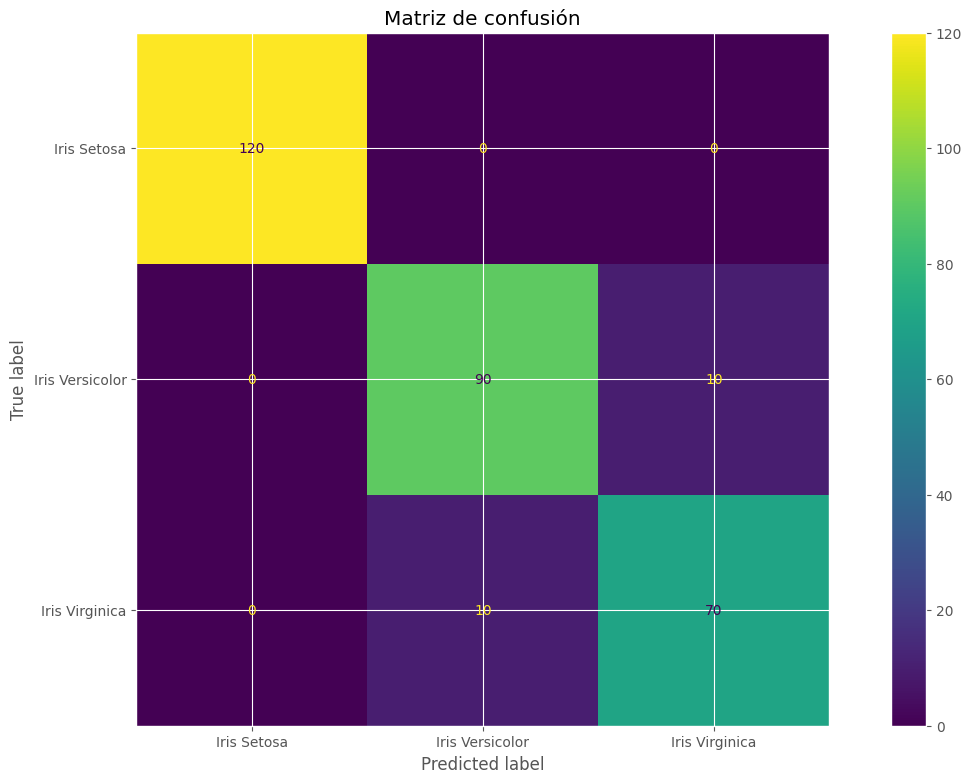

In [24]:
cmxd_plot = ConfusionMatrixDisplay(confusion_matrix=global_confusion_matrix, display_labels=['Iris Setosa', 'Iris Versicolor', 'Iris Virginica'])

cmxd_plot.plot()
plt.title("Matriz de confusión")
plt.show()

In [ ]:
import re

report_str = classification_report(y_test, y_predic)
print(report_str)


# Crear un mapeo de clases
class_mapping = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}

# Usar expresiones regulares para extraer las métricas
pattern = r'(\S+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+(\d+)'
matches = re.findall(pattern, report_str)

# Crear un DataFrame a partir de las coincidencias
data = []
for match in matches:
    class_name, precision, recall, f1, support = match
    precision, recall, f1, support = map(float, (precision, recall, f1, support))
    data.append([class_name, precision, recall, f1, int(support)])

# Cambiar los nombres de las clases
for row in data:
    row[0] = class_mapping.get(row[0], row[0])

report_df = pd.DataFrame(data, columns=["class", "precision", "recall", "f1-score", "support"])

# Renombrar las clases
class_names = {
    0: 'Iris-setosa',
    1: 'Iris-versicolor',
    2: 'Iris-virginica'
}
report_df['class'] = report_df['class'].map(class_names)

report_df

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.83      0.91        12
 Iris-virginica       0.80      1.00      0.89         8

       accuracy                           0.93        30
      macro avg       0.93      0.94      0.93        30
   weighted avg       0.95      0.93      0.93        30



,class,precision,recall,f1-score,support
0,Iris-setosa,1.00,1.00,1.00,10
1,Iris-versicolor,1.00,0.83,0.91,12
2,Iris-virginica,0.80,1.00,0.89,8
3,NaN,0.93,0.94,0.93,30
4,NaN,0.95,0.93,0.93,30


Para finalmente, imprimir el reporte de clasificación el cual muestra algunas de las métricas más usadas en una matriz.

In [ ]:
print(classification_report(Y_test, Y_predic))
print(confusion_matrix(Y_test, Y_predic))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.73      1.00      0.84         8
 Iris-virginica       1.00      0.75      0.86        12

       accuracy                           0.90        30
      macro avg       0.91      0.92      0.90        30
   weighted avg       0.93      0.90      0.90        30

[[10  0  0]
 [ 0  8  0]
 [ 0  3  9]]


Nos damos cuenta que gracias a que al principio escogimos un $k$ óptimo, nuestras métricas están suficientemente altas como para aprobar el aprendizaje por parte del modelo y luego poder implementarlo con nuevos datos. Sin embargo, esto no quita el hecho de que se puede realizar un posterior análisis a las métricas obtenidas donde para ello usaremos la *matriz de confusión* proveniente del método `confusion_matrix` y para visualizar lo obtenido con el método `ConfusionMatrixDisplay`.

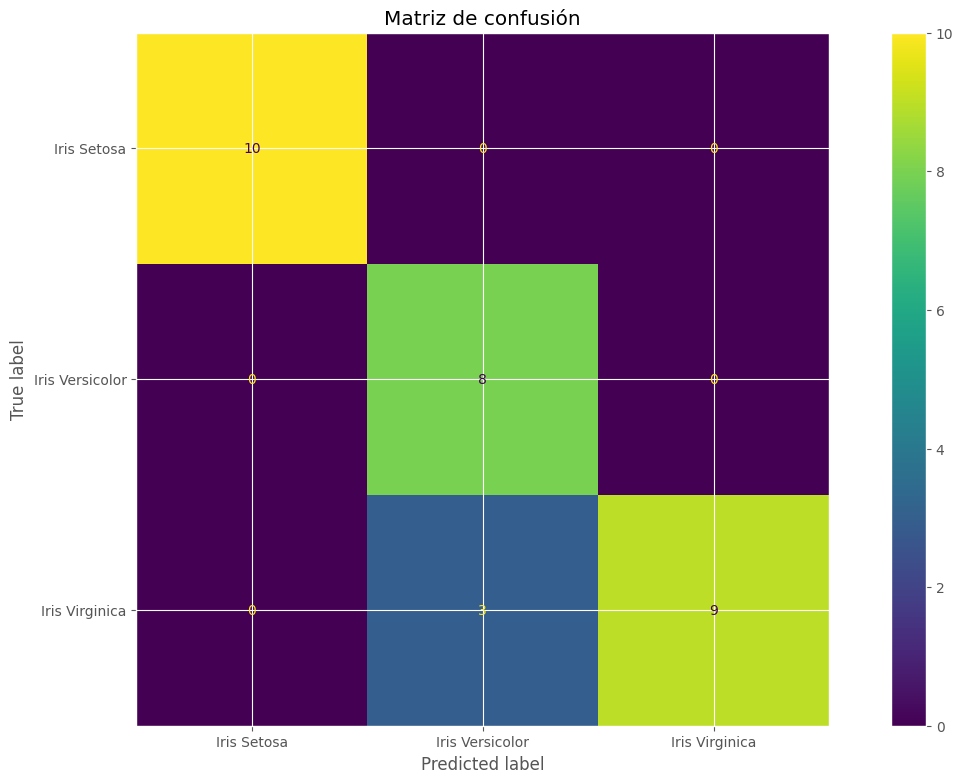

In [ ]:
cm = confusion_matrix(Y_test, Y_predic)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Iris Setosa', 'Iris Versicolor', 'Iris Virginica'])

cm_plot.plot()
plt.title("Matriz de confusión")
plt.show()

Así nos podemos volver a dar cuenta que hubo una buena predicción por parte del modelo.

## Visualización de las regiones generadas por *k-NN*

Ahora, realizaremos el proceso análogo al anterior solo que ahora con el objetivo de ver las regiones que dibuja el método *k-NN*, regiones en dónde se encontrarían los datos tanto en la predicción con en la evaluación.

Primero es pertinente volver a llamar el dataset de *Iris* y volverlo a cargar también ya que si se toma directamente de *sklearn* tenemos un mejor manejo de los datos, esta situación no se hizo con anterioridad ya que lo que se priorizaba era la muestra de los datos.

### Gestión de los datos

Cargar los datos del dataset *Iris* dado por *sklearn*.

In [ ]:
# Carga del dataset "Iris"
iris = datasets.load_iris()
X = iris.data[:, [1, 3]]  # Solo tomamos dos características, la segunda y cuarta columna
Y = iris.target # Tomamos la última columna que es la que viene por defecto

División, instanciamiento y entrenamiento del modelo.

In [ ]:
# Se realiza la división de los datos con "train_test_split"
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.20, random_state = 69)

# Se instancia un objeto (veci) con la clasificación k-NN
veci = KNeighborsClassifier(3, weights='distance')

# Entrenamiento del modelo
veci.fit(X_train, Y_train)

KNeighborsClassifier(n_neighbors=3, weights='distance')

### Regiones dibujadas

Tras haber realizado nuevamente la gestión rápida de los datos y el entrenamiento del modelo, se utiliza el siguiente fragmento de código el cual grafica a precisión las regiones dibujadas por el modelo.

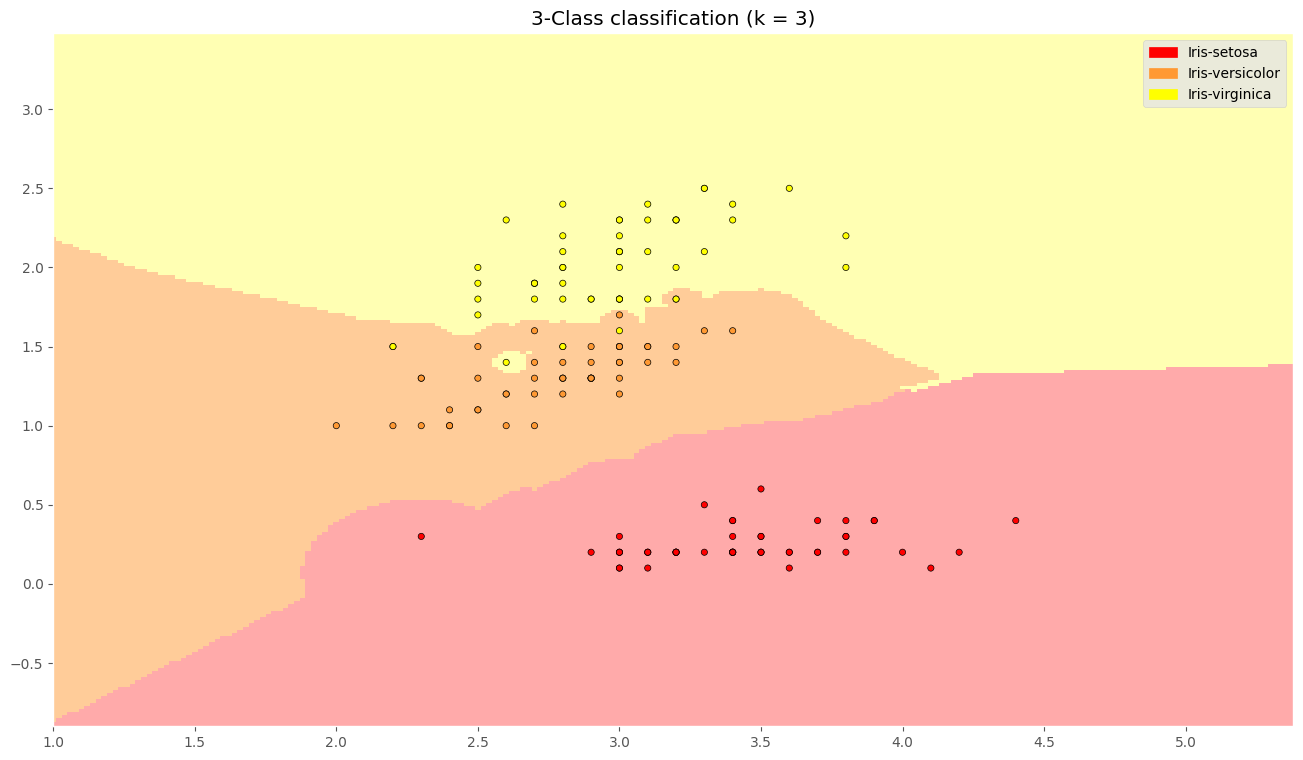

In [ ]:
# Creación de los mapas de colores
cmap_light = ListedColormap(['#FFAAAA', '#ffcc99', '#ffffb3'])
cmap_bold = ListedColormap(['#FF0000', '#ff9933', '#FFFF00'])

# Graficar las condiciones de frontera
h = .02  # Paso de tamaño de la malla
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = veci.predict(np.c_[xx.ravel(), yy.ravel()]) # Predicción

# Poner el resultado de la predicción del modelo en una gráfica de colores
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Graficar también el resto de datos en general
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=cmap_bold, edgecolor='k', s=20)

# Añadir leyendas como convenciones
patch0 = mpatches.Patch(color='#FF0000', label='Iris-setosa')
patch1 = mpatches.Patch(color='#ff9933', label='Iris-versicolor')
patch2 = mpatches.Patch(color='#FFFF00', label='Iris-virginica')
plt.legend(handles=[patch0, patch1, patch2])

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("3-Class classification (k = %i)" % n_neighbors)

plt.show()

Dando así finalización al ejercicio.

## Conclusión

Se puede concluir que el método *k-NN* es un buen método de clasificación para el trabajo en este dataset donde se destaca que tuvimos suerte al encontrar un $k$ óptimo pequeño el cual es suficiente para tener unas buenas métricas, sin embargo, nada nos garantiza que la búsqueda de ese $k$ óptimo sea así de sencilla en la vida cotidiana.

Finalmente, al dibujar las regiones nos podemos dar cuenta que hay datos que están fuera de la región donde deberían estar pero si nos remitimos a la primera gráfica de visualización de datos se puede ver que hay datos superpuestos sobre otros con las mismas etiquetas por lo que en principio eso puede justificar el porqué ocurrió eso a la hora de graficar las regiones.